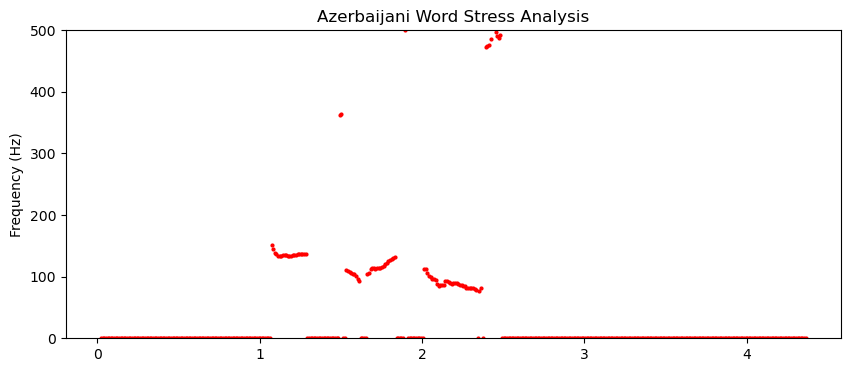

图表生成成功！


In [1]:
import parselmouth
import matplotlib.pyplot as plt

# 注意：请确保你已经把录音文件拖进了左侧的文件夹，并把下方的文件名改对
audio_file = "Tky-Recording-1.wav" 

try:
    snd = parselmouth.Sound(audio_file)
    pitch = snd.to_pitch()
    
    # 开始绘图
    plt.figure(figsize=(10, 4))
    plt.plot(pitch.xs(), pitch.selected_array['frequency'], 'ro', markersize=2)
    plt.ylim(0, 500)
    plt.ylabel("Frequency (Hz)")
    plt.title("Azerbaijani Word Stress Analysis")
    plt.show()
    print("图表生成成功！")
except Exception as e:
    print(f"出错啦: {e}。请检查文件名是否正确，或者是否已将录音拖入左侧列表。")

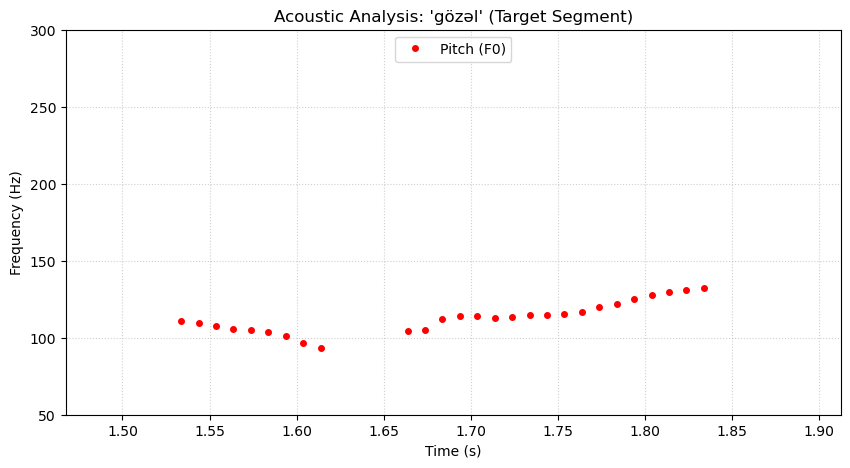

成功截取目标词！分析区间：1.46753s 至 1.91232s


In [2]:
import parselmouth
import matplotlib.pyplot as plt

# 确保文件名一致
audio_file = "Tky-Recording-1.wav"

try:
    snd = parselmouth.Sound(audio_file)
    pitch = snd.to_pitch()
    
    plt.figure(figsize=(10, 5))
    
    # 绘图：用红色的点表示每一个 Pitch 采样
    plt.plot(pitch.xs(), pitch.selected_array['frequency'], 'ro', markersize=4, label="Pitch (F0)")
    
    # --- 核心：填入你在 Praat 里测得的精准时间戳 ---
    plt.xlim(1.467530, 1.912320)  
    
    # 将纵坐标固定在语音常见的范围，让曲线更饱满
    plt.ylim(50, 300)     
    
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title("Acoustic Analysis: 'gözəl' (Target Segment)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    print(f"成功截取目标词！分析区间：{1.467530}s 至 {1.912320}s")
except Exception as e:
    print(f"运行出错: {e}")

In [ ]:
import os
import parselmouth
import pandas as pd

# 1. Define the academic word list from your research paper mapping (1-20)
WORD_LIST = {
    "01": "gözəl", "02": "təmiz", "03": "dərin", "04": "qalın", "05": "çürük",
    "06": "soyuq", "07": "geniş", "08": "yaman", "09": "sərin", "10": "dayaz",
    "11": "çətin", "12": "yaşıl", "13": "alçaq", "14": "qısa", "15": "dolu",
    "16": "qara", "17": "yazıq", "18": "yalın", "19": "çevik", "20": "soluq"
}

def scan_speech_corpus(base_dir, group_label):
    """
    Scans the specific audio directory, validates filenames, maps them to the word list,
    and extracts phonetic metadata using Parselmouth.
    """
    report_data = []
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return report_data
        
    print(f"Scanning {group_label} group in '{base_dir}'...")
    
    # Loop through all files
    for filename in os.listdir(base_dir):
        if filename.endswith(".wav"):
            file_path = os.path.join(base_dir, filename)
            
            # Parse the 3-tier naming convention (e.g., L1_01_01.wav)
            name_parts = filename.replace(".wav", "").split("_")
            
            if len(name_parts) == 3:
                group, subject_id, word_id = name_parts
                
                # Map the sentence/word ID to the actual Azerbaijani word
                target_word = WORD_LIST.get(word_id, "Unknown Word")
                
                try:
                    # Sound analysis using Parselmouth
                    snd = parselmouth.Sound(file_path)
                    duration = snd.get_total_duration()
                    sampling_rate = snd.sampling_frequency
                    
                    report_data.append({
                        "Group": group,
                        "Subject": f"Subject_{subject_id}",
                        "Word ID": word_id,
                        "Target Word": target_word,
                        "Duration (s)": round(duration, 3),
                        "Sampling Rate (Hz)": sampling_rate,
                        "Status": "OK"
                    })
                except Exception as e:
                    print(f"⚠️ Error reading file {filename}: {e}")
            else:
                print(f"❌ Warning: Filename '{filename}' does not follow the 3-tier convention!")
                
    return report_data

# =========================================================
# EXECUTE CORPUS AUDIT
# =========================================================
learner_path = "/audio/learner/"
native_path = "/audio/native/"

all_results = []
all_results.extend(scan_speech_corpus(learner_path, "L2 Learners"))
all_results.extend(scan_speech_corpus(native_path, "L1 Native Speakers"))

# Convert to pandas DataFrame for premium visual presentation
if all_results:
    corpus_df = pd.DataFrame(all_results)
    # Sort for beautiful structure
    corpus_df = corpus_df.sort_values(by=["Group", "Subject", "Word ID"])
    
    print("\n" + "="*25 + " SPEECH CORPUS AUDIT REPORT " + "="*25)
    print(f"Total valid speech samples found: {len(corpus_df)} / 200")
    print("="*76)
    print(corpus_df.to_string(index=False))
else:
    print("No valid audio files detected. Please verify your file placement.")

Directory not found: ../audio/learner/
Directory not found: ../audio/native/
No valid audio files detected. Please verify your file placement.


In [4]:
import os
import parselmouth
import pandas as pd

# 1. Define the academic word list from your research paper mapping (1-20)
WORD_LIST = {
    "01": "gözəl", "02": "təmiz", "03": "dərin", "04": "qalın", "05": "çürük",
    "06": "soyuq", "07": "geniş", "08": "yaman", "09": "sərin", "10": "dayaz",
    "11": "çətin", "12": "yaşıl", "13": "alçaq", "14": "qısa", "15": "dolu",
    "16": "qara", "17": "yazıq", "18": "yalın", "19": "çevik", "20": "soluq"
}

def scan_speech_corpus(base_dir, group_label):
    """
    Scans the specific audio directory, validates filenames, maps them to the word list,
    and extracts phonetic metadata using Parselmouth.
    """
    report_data = []
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return report_data
        
    print(f"Scanning {group_label} group in '{base_dir}'...")
    
    # Loop through all files
    for filename in os.listdir(base_dir):
        if filename.endswith(".wav"):
            file_path = os.path.join(base_dir, filename)
            
            # Parse the 3-tier naming convention (e.g., L1_01_01.wav)
            name_parts = filename.replace(".wav", "").split("_")
            
            if len(name_parts) == 3:
                group, subject_id, word_id = name_parts
                
                # Map the sentence/word ID to the actual Azerbaijani word
                target_word = WORD_LIST.get(word_id, "Unknown Word")
                
                try:
                    # Sound analysis using Parselmouth
                    snd = parselmouth.Sound(file_path)
                    duration = snd.get_total_duration()
                    sampling_rate = snd.sampling_frequency
                    
                    report_data.append({
                        "Group": group,
                        "Subject": f"Subject_{subject_id}",
                        "Word ID": word_id,
                        "Target Word": target_word,
                        "Duration (s)": round(duration, 3),
                        "Sampling Rate (Hz)": sampling_rate,
                        "Status": "OK"
                    })
                except Exception as e:
                    print(f"⚠️ Error reading file {filename}: {e}")
            else:
                print(f"❌ Warning: Filename '{filename}' does not follow the 3-tier convention!")
                
    return report_data

# =========================================================
# EXECUTE CORPUS AUDIT (PERFECTLY ALIGNED WITH YOUR PATHS)
# =========================================================
# Removed '../' and updated with your exact folder names
learner_path = "audio/L2_learners_Chinese/"
native_path = "audio/Native_Speakers/"

all_results = []
all_results.extend(scan_speech_corpus(learner_path, "L2 Learners"))
all_results.extend(scan_speech_corpus(native_path, "L1 Native Speakers"))

# Convert to pandas DataFrame for premium visual presentation
if all_results:
    corpus_df = pd.DataFrame(all_results)
    # Sort for beautiful structure
    corpus_df = corpus_df.sort_values(by=["Group", "Subject", "Word ID"])
    
    print("\n" + "="*25 + " SPEECH CORPUS AUDIT REPORT " + "="*25)
    print(f"Total valid speech samples found: {len(corpus_df)} / 200")
    print("="*76)
    print(corpus_df.to_string(index=False))
else:
    print("No valid audio files detected. Please verify your file placement.")

Scanning L2 Learners group in 'audio/L2_learners_Chinese/'...
Scanning L1 Native Speakers group in 'audio/Native_Speakers/'...

========================= SPEECH CORPUS AUDIT REPORT =========================
Total valid speech samples found: 195 / 200
Group    Subject Word ID Target Word  Duration (s)  Sampling Rate (Hz) Status
   L1 Subject_01      01       gözəl         2.891             44100.0     OK
   L1 Subject_01      05       çürük         3.300             44100.0     OK
   L1 Subject_01      06       soyuq         3.110             44100.0     OK
   L1 Subject_01      07       geniş         3.180             44100.0     OK
   L1 Subject_01      08       yaman         3.168             44100.0     OK
   L1 Subject_01      09       sərin         3.364             44100.0     OK
   L1 Subject_01      10       dayaz         3.770             44100.0     OK
   L1 Subject_01      11       çətin         2.929             44100.0     OK
   L1 Subject_01      12       yaşıl         3.

In [8]:
# =========================================================
# FIND MISSING AUDIO FILES
# =========================================================

print("=== MISSING FILES DETECTED ===")
missing_count = 0

# Loop through both groups
for group_prefix, group_dir in [("L1", "audio/Native_Speakers/"), ("L2", "audio/L2_learners_Chinese/")]:
    # Loop through all 5 subjects
    for sub in range(1, 6):
        subject_id = f"{sub:02d}"
        
        # Loop through all 20 target words
        for word_id, word_name in WORD_LIST.items():
            # Construct the file name that SHOULD exist
            expected_filename = f"{group_prefix}_{subject_id}_{word_id}.wav"
            expected_path = os.path.join(group_dir, expected_filename)
            
            # Check if it exists
            if not os.path.exists(expected_path):
                missing_count += 1
                print(f"❌ Missing [{missing_count}]: {expected_filename} (Subject {subject_id} | Word: '{word_name}')")

if missing_count == 0:
    print("🎉 Amazing! No missing files found. All 200 items are present!")
else:
    print(f"\nTotal Missing Files: {missing_count}")

=== MISSING FILES DETECTED ===
❌ Missing [1]: L1_04_02.wav (Subject 04 | Word: 'təmiz')
❌ Missing [2]: L1_04_19.wav (Subject 04 | Word: 'çevik')

Total Missing Files: 2


In [9]:
import os
import math
import tgt
import parselmouth
import pandas as pd

def extract_academic_parameters(wav_path, tg_path):
    """
    Extracts acoustic metrics strictly following the operational definitions
    in Section 4.4 of the thesis: Syllabic Duration, Mean/Max Intensity, 
    and F0 converted to Semitones (St).
    """
    if not os.path.exists(tg_path):
        return None
        
    try:
        # Load the annotated Praat TextGrid file
        tg = tgt.io.read_textgrid(tg_path, encoding='utf-8')
        
        # Load the raw audio file via Parselmouth for Digital Signal Processing (DSP)
        sound = parselmouth.Sound(wav_path)
        pitch = sound.to_pitch()
        intensity = sound.to_intensity()
        
        # Fetch the predefined 'syllable' tier for core duration and prosodic analysis
        syllable_tier = tg.get_tier_by_name('syllable')
        
        # Filter out empty intervals to capture only valid target syllables (S1 and S2)
        syllables = [inv for inv in syllable_tier if inv.text.strip()]
        
        if len(syllables) < 2:
            return None
            
        data_row = {}
        
        # Iterating through Syllable 1 (Non-stressed) and Syllable 2 (Final-stressed)
        for idx, syl in enumerate(syllables[:2], start=1):
            label = syl.text
            start = syl.start_time
            end = syl.end_time
            
            # Metric 1: Total temporal length of the entire syllable (converted to milliseconds)
            duration_ms = (end - start) * 1000 
            
            # Metric 2: Extract Mean and Maximum Intensity within the segmented boundaries
            mean_intensity = parselmouth.praat.call(intensity, "Get mean...", start, end, "energy")
            max_intensity = parselmouth.praat.call(intensity, "Get maximum...", start, end, "Parabolic")
            
            # Metric 3: Extract Mean F0 (Hz) and convert to Semitones (St) relative to 100 Hz baseline
            mean_f0_hz = parselmouth.praat.call(pitch, "Get mean...", start, end, "Hertz")
            
            mean_f0_st = None
            if not pd.isna(mean_f0_hz) and mean_f0_hz > 0:
                # Operational Formula: St = 12 * log2(Hz / 100)
                mean_f0_st = 12 * math.log2(mean_f0_hz / 100)
                
            # Populate data structure with standardized linguistic column headers
            data_row[f"S{idx} Label"] = label
            data_row[f"S{idx} Duration (ms)"] = round(duration_ms, 2)
            data_row[f"S{idx} Mean Intensity (dB)"] = round(mean_intensity, 2)
            data_row[f"S{idx} Max Intensity (dB)"] = round(max_intensity, 2)
            data_row[f"S{idx} Mean F0 (Hz)"] = round(mean_f0_hz, 2) if not pd.isna(mean_f0_hz) else None
            data_row[f"S{idx} Mean F0 (St)"] = round(mean_f0_st, 2) if mean_f0_st else None

        # --- Automated Correlate Analysis as specified in Thesis Section 4.4 ---
        # Requirement 2: Calculate the relative intensity difference (S2 - S1)
        data_row["Intensity Diff (S2-S1 dB)"] = round(
            data_row["S2 Mean Intensity (dB)"] - data_row["S1 Mean Intensity (dB)"], 2
        )
        
        # Requirement 1: Calculate the duration ratio for prosodic final lengthening evaluation
        data_row["Duration Ratio (S2/S1)"] = round(
            data_row["S2 Duration (ms)"] / data_row["S1 Duration (ms)"], 2
        )
        
        return data_row
        
    except Exception as e:
        print(f"⚠️ Error processing {os.path.basename(wav_path)}: {e}")
        return None

# Initialize the acoustic core engine
print("✅ Acoustic extraction engine successfully initialized with full English documentation.")

✅ Acoustic extraction engine successfully initialized with full English documentation.


In [2]:
import os
from scipy.io import wavfile

# 1. Specify the relative path to the audio directory
audio_dir = 'audio/'

print("🚀 Starting batch conversion to mono...")
converted_count = 0

# 2. Iterate through all WAV files in the directory
for filename in os.listdir(audio_dir):
    if filename.endswith('.wav') or filename.endswith('.WAV'):
        filepath = os.path.join(audio_dir, filename)
        
        # Read the sample rate and audio data
        sample_rate, data = wavfile.read(filepath)
        
        # Check if the audio is stereo (2 channels)
        if len(data.shape) > 1 and data.shape[1] == 2:
            # Extract the left channel (Channel 1) to convert to mono
            mono_data = data[:, 0]
            
            # Overwrite the original file to keep filenames perfectly aligned with TextGrids
            wavfile.write(filepath, sample_rate, mono_data)
            print(f"✅ Successfully converted: {filename} -> Mono")
            converted_count += 1

print(f"🎉 Done! Processed {converted_count} audio files. All files in '{audio_dir}' are now standardized to mono!")

🚀 Starting batch conversion to mono...
🎉 Done! Processed 0 audio files. All files in 'audio/' are now standardized to mono!


In [3]:
import os
from scipy.io import wavfile

# 1. Specify the relative path to the root audio directory
audio_dir = 'audio/'

print("🚀 Starting recursive batch conversion to mono...")
converted_count = 0

# 2. Use os.walk to recursively search through all nested subdirectories
for root, dirs, files in os.walk(audio_dir):
    for filename in files:
        if filename.endswith('.wav') or filename.endswith('.WAV'):
            filepath = os.path.join(root, filename)
            
            try:
                # Read the sample rate and audio data
                sample_rate, data = wavfile.read(filepath)
                
                # Check if the audio is stereo (2 channels)
                if len(data.shape) > 1 and data.shape[1] == 2:
                    # Extract the left channel (Channel 1) to convert to mono
                    mono_data = data[:, 0]
                    
                    # Overwrite the original file to keep filenames perfectly aligned with TextGrids
                    wavfile.write(filepath, sample_rate, mono_data)
                    
                    # Get the relative path for a cleaner print log
                    display_path = os.path.relpath(filepath, audio_dir)
                    print(f"✅ Successfully converted: {display_path} -> Mono")
                    converted_count += 1
            except Exception as e:
                print(f"❌ Error processing {filename}: {e}")

print(f"\n🎉 Done! Processed {converted_count} audio files across all subdirectories.")
print(f"All nested files in '{audio_dir}' are now standardized to mono!")

🚀 Starting recursive batch conversion to mono...
✅ Successfully converted: 学习组的副本/L2_01/L2_01_14.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_15.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_01.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_17.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_03.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_02.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_16.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_12.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_06.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_07.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_13.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_05.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_11.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_10.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_04.wav -> Mono
✅ Successfully converted: 学习组的副本/L2_01/L2_01_09.wav